# 🍔***Zomato Restaurant Performance Analysis***

## INFORMATION

This analysis uses the Zomato Dataset, which contains comprehensive restaurant data from Bangalore, India. The dataset comprises 60,782 restaurant records with 17 different attributes including restaurant name, location, rating, cost, restaurant type, cuisines, and online ordering availability.

The dataset was collected from Zomato's restaurant listings and includes essential information about dining establishments across multiple neighborhoods in Bangalore. Each record provides details about a restaurant's service features, pricing, cuisines offered, and customer ratings.

The original dataset contains the following columns:
- Restaurant identifiers: name, URL, address, phone
- Service features: online_order, book_table
- Customer feedback: rate (rating out of 5), reviews_list
- Operational details: location, rest_type, cuisines, menu_item, dish_liked
- Pricing: approx_cost(for two people)
- Categorization: listed_in(type), listed_in(city)

## PROBLEM STATEMENT

The primary objective of this analysis is to extract meaningful insights from Bangalore's restaurant ecosystem to answer the following key questions:

1. **Location Analysis**: Which areas in Bangalore have the highest concentration of restaurants and the best average ratings?

2. **Cost vs. Quality**: Is there a correlation between restaurant pricing and customer ratings? Do expensive restaurants necessarily have better reviews?

3. **Restaurant Type Insights**: What are the most common types of restaurants in Bangalore? How does average cost vary across different restaurant categories?

4. **Value Discovery**: Which restaurants offer the best value proposition - high ratings (≥4.0) with affordable pricing (≤₹350 for two people)?

5. **Data Quality**: How much missing data exists in the dataset and what impact does it have on analysis?

Through this analysis, we aim to help both consumers find restaurants that match their budget and preferences, and business analysts understand market trends in Bangalore's food service industry.

### Data Preparation

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [30]:
df = pd.read_csv("Zomato Dataset Replaced.csv", encoding='latin1')
df

,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
0,https://www.zomato.com/bangalore/jalsa-banasha...,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet,Banashankari
1,https://www.zomato.com/bangalore/spice-elephan...,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet,Banashankari
2,https://www.zomato.com/SanchurroBangalore?cont...,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8/5,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,"[('Rated 3.0', ""RATED\n Ambience is not that ...",[],Buffet,Banashankari
3,https://www.zomato.com/bangalore/addhuri-udupi...,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7/5,88,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,"[('Rated 4.0', ""RATED\n Great food and proper...",[],Buffet,Banashankari
4,https://www.zomato.com/bangalore/grand-village...,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8/5,166,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,"[('Rated 4.0', 'RATED\n Very good restaurant ...",[],Buffet,Banashankari
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60777,https://www.zomato.com/bangalore/best-brews-fo...,"Four Points by Sheraton Bengaluru, 43/3, White...",Best Brews - Four Points by Sheraton Bengaluru...,No,No,3.6 /5,27,080 40301477,Whitefield,Bar,NaN,Continental,"1,500","[('Rated 5.0', ""RATED\n Food and service are ...",[],Pubs and bars,Whitefield
60778,https://www.zomato.com/bangalore/vinod-bar-and...,"Number 10, Garudachar Palya, Mahadevapura, Whi...",Vinod Bar And Restaurant,No,No,NaN,0,+91 8197675843,Whitefield,Bar,NaN,Finger Food,600,[],[],Pubs and bars,Whitefield
60779,https://www.zomato.com/bangalore/plunge-sherat...,Sheraton Grand Bengaluru Whitefield Hotel & Co...,Plunge - Sheraton Grand Bengaluru Whitefield H...,No,No,NaN,0,NaN,Whitefield,Bar,NaN,Finger Food,"2,000",[],[],Pubs and bars,Whitefield
60780,https://www.zomato.com/bangalore/chime-sherato...,Sheraton Grand Bengaluru Whitefield Hotel & Co...,Chime - Sheraton Grand Bengaluru Whitefield Ho...,No,Yes,4.3 /5,236,080 49652769,"ITPL Main Road, Whitefield",Bar,"Cocktails, Pizza, Buttermilk",Finger Food,"2,500","[('Rated 4.0', 'RATED\n Nice and friendly pla...",[],Pubs and bars,Whitefield


### Data Exploration

In [31]:
df.head(15)

,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
0,https://www.zomato.com/bangalore/jalsa-banasha...,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet,Banashankari
1,https://www.zomato.com/bangalore/spice-elephan...,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet,Banashankari
2,https://www.zomato.com/SanchurroBangalore?cont...,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8/5,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,"[('Rated 3.0', ""RATED\n Ambience is not that ...",[],Buffet,Banashankari
3,https://www.zomato.com/bangalore/addhuri-udupi...,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7/5,88,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,"[('Rated 4.0', ""RATED\n Great food and proper...",[],Buffet,Banashankari
4,https://www.zomato.com/bangalore/grand-village...,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8/5,166,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,"[('Rated 4.0', 'RATED\n Very good restaurant ...",[],Buffet,Banashankari
5,https://www.zomato.com/bangalore/timepass-dinn...,"37, 5-1, 4th Floor, Bosco Court, Gandhi Bazaar...",Timepass Dinner,Yes,No,3.8/5,286,+91 9980040002\r\n+91 9980063005,Basavanagudi,Casual Dining,"Onion Rings, Pasta, Kadhai Paneer, Salads, Sal...",North Indian,600,"[('Rated 3.0', 'RATED\n Food 3/5\nAmbience 3/...",[],Buffet,Banashankari
6,https://www.zomato.com/bangalore/rosewood-inte...,"19/1, New Timberyard Layout, Beside Satellite ...",Rosewood International Hotel - Bar & Restaurant,No,No,3.6/5,8,+91 9731716688\r\n080 26740366,Mysore Road,Casual Dining,NaN,"North Indian, South Indian, Andhra, Chinese",800,"[('Rated 5.0', 'RATED\n Awesome food ??Great ...",[],Buffet,Banashankari
7,https://www.zomato.com/bangalore/onesta-banash...,"2469, 3rd Floor, 24th Cross, Opposite BDA Comp...",Onesta,Yes,Yes,4.6/5,2556,080 48653961\r\n080 48655715,Banashankari,"Casual Dining, Cafe","Farmhouse Pizza, Chocolate Banana, Virgin Moji...","Pizza, Cafe, Italian",600,"[('Rated 5.0', 'RATED\n I personally really l...",[],Cafes,Banashankari
8,https://www.zomato.com/bangalore/penthouse-caf...,"1, 30th Main Road, 3rd Stage, Banashankari, Ba...",Penthouse Cafe,Yes,No,4.0/5,324,+91 8884135549\r\n+91 9449449316,Banashankari,Cafe,"Pizza, Mocktails, Coffee, Nachos, Salad, Pasta...","Cafe, Italian, Continental",700,"[('Rated 3.0', ""RATED\n I had been to this pl...",NaN,NaN,NaN
9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


* As it is clearly visible in above data that the row no.9 is colmpletely empty and it's not only one there are too many rows like that where every column has null values

In [32]:
df.tail(8)

,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
60774,https://www.zomato.com/bangalore/the-farm-hous...,"136, SAP Labs India, KIADB Export Promotion In...",The Farm House Bar n Grill,No,No,3.7 /5,34,+91 9980121279\n+91 9900240646,Whitefield,"Casual Dining, Bar",NaN,"North Indian, Continental",800,"[('Rated 4.0', 'RATED\n Ambience- Big and spa...",[],Pubs and bars,Whitefield
60775,https://www.zomato.com/bangalore/topsy-turvey-...,"2E2, 4th Cross Road, Devasandra Industrial Est...",Topsy Turvey,No,No,NaN,0,+91 9148155994,Whitefield,Bar,NaN,Finger Food,900,"[('Rated 4.0', ""RATED\n A divine joint for Fl...",[],Pubs and bars,Whitefield
60776,https://www.zomato.com/bangalore/bhagini-2-whi...,"139/C1, Next To GR Tech Park, Pattandur Agraha...",Bhagini,No,No,2.5 /5,81,080 65951222,Whitefield,"Casual Dining, Bar","Biryani, Andhra Meal","Andhra, South Indian, Chinese, North Indian",800,"[('Rated 4.0', 'RATED\n A fine place to chill...",[],Pubs and bars,Whitefield
60777,https://www.zomato.com/bangalore/best-brews-fo...,"Four Points by Sheraton Bengaluru, 43/3, White...",Best Brews - Four Points by Sheraton Bengaluru...,No,No,3.6 /5,27,080 40301477,Whitefield,Bar,NaN,Continental,"1,500","[('Rated 5.0', ""RATED\n Food and service are ...",[],Pubs and bars,Whitefield
60778,https://www.zomato.com/bangalore/vinod-bar-and...,"Number 10, Garudachar Palya, Mahadevapura, Whi...",Vinod Bar And Restaurant,No,No,NaN,0,+91 8197675843,Whitefield,Bar,NaN,Finger Food,600,[],[],Pubs and bars,Whitefield
60779,https://www.zomato.com/bangalore/plunge-sherat...,Sheraton Grand Bengaluru Whitefield Hotel & Co...,Plunge - Sheraton Grand Bengaluru Whitefield H...,No,No,NaN,0,NaN,Whitefield,Bar,NaN,Finger Food,"2,000",[],[],Pubs and bars,Whitefield
60780,https://www.zomato.com/bangalore/chime-sherato...,Sheraton Grand Bengaluru Whitefield Hotel & Co...,Chime - Sheraton Grand Bengaluru Whitefield Ho...,No,Yes,4.3 /5,236,080 49652769,"ITPL Main Road, Whitefield",Bar,"Cocktails, Pizza, Buttermilk",Finger Food,"2,500","[('Rated 4.0', 'RATED\n Nice and friendly pla...",[],Pubs and bars,Whitefield
60781,https://www.zomato.com/bangalore/the-nest-the-...,"ITPL Main Road, KIADB Export Promotion Industr...",The Nest - The Den Bengaluru,No,No,3.4 /5,13,+91 8071117272,"ITPL Main Road, Whitefield","Bar, Casual Dining",NaN,"Finger Food, North Indian, Continental","1,500","[('Rated 5.0', 'RATED\n Great ambience , look...",[],Pubs and bars,Whitefield


In [33]:
# Getting info of dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 60782 entries, 0 to 60781
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   url                          56200 non-null  str  
 1   address                      56235 non-null  str  
 2   name                         56236 non-null  str  
 3   online_order                 56234 non-null  str  
 4   book_table                   56194 non-null  str  
 5   rate                         48414 non-null  str  
 6   votes                        56174 non-null  str  
 7   phone                        54956 non-null  str  
 8   location                     56128 non-null  str  
 9   rest_type                    55914 non-null  str  
 10  dish_liked                   28049 non-null  str  
 11  cuisines                     56049 non-null  str  
 12  approx_cost(for two people)  55745 non-null  str  
 13  reviews_list                 56063 non-null  str  
 14  m

* Every columns have String Datatypes

In [34]:
df.isnull().sum()

url                             4582
address                         4547
name                            4546
online_order                    4548
book_table                      4588
rate                           12368
votes                           4608
phone                           5826
location                        4654
rest_type                       4868
dish_liked                     32733
cuisines                        4733
approx_cost(for two people)     5037
reviews_list                    4719
menu_item                       9098
listed_in(type)                 9127
listed_in(city)                 9156
dtype: int64

In [35]:
df.duplicated().sum()

np.int64(4745)

### Data Cleaning:
* Removing unwanted Columns and Rows
* Earlier we saw that row no.9 is completely empty and there are many other. Removing it completely
* Fixing format and data type of Ratings
* Converting Approx Cost to Numbers

1. Removing unwanted Columns and Rows

In [36]:
df = df.drop(columns=['url', 'address', 'book_table', 'votes', 'dish_liked', 'reviews_list', 'menu_item'])
df

,name,online_order,rate,phone,location,rest_type,cuisines,approx_cost(for two people),listed_in(type),listed_in(city)
0,Jalsa,Yes,4.1/5,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"North Indian, Mughlai, Chinese",800,Buffet,Banashankari
1,Spice Elephant,Yes,4.1/5,080 41714161,Banashankari,Casual Dining,"Chinese, North Indian, Thai",800,Buffet,Banashankari
2,San Churro Cafe,Yes,3.8/5,+91 9663487993,Banashankari,"Cafe, Casual Dining","Cafe, Mexican, Italian",800,Buffet,Banashankari
3,Addhuri Udupi Bhojana,No,3.7/5,+91 9620009302,Banashankari,Quick Bites,"South Indian, North Indian",300,Buffet,Banashankari
4,Grand Village,No,3.8/5,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,"North Indian, Rajasthani",600,Buffet,Banashankari
...,...,...,...,...,...,...,...,...,...,...
60777,Best Brews - Four Points by Sheraton Bengaluru...,No,3.6 /5,080 40301477,Whitefield,Bar,Continental,"1,500",Pubs and bars,Whitefield
60778,Vinod Bar And Restaurant,No,NaN,+91 8197675843,Whitefield,Bar,Finger Food,600,Pubs and bars,Whitefield
60779,Plunge - Sheraton Grand Bengaluru Whitefield H...,No,NaN,NaN,Whitefield,Bar,Finger Food,"2,000",Pubs and bars,Whitefield
60780,Chime - Sheraton Grand Bengaluru Whitefield Ho...,No,4.3 /5,080 49652769,"ITPL Main Road, Whitefield",Bar,Finger Food,"2,500",Pubs and bars,Whitefield


2. Removing empty rows

In [37]:
df = df.dropna(how='all')
df[:10]

,name,online_order,rate,phone,location,rest_type,cuisines,approx_cost(for two people),listed_in(type),listed_in(city)
0,Jalsa,Yes,4.1/5,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"North Indian, Mughlai, Chinese",800,Buffet,Banashankari
1,Spice Elephant,Yes,4.1/5,080 41714161,Banashankari,Casual Dining,"Chinese, North Indian, Thai",800,Buffet,Banashankari
2,San Churro Cafe,Yes,3.8/5,+91 9663487993,Banashankari,"Cafe, Casual Dining","Cafe, Mexican, Italian",800,Buffet,Banashankari
3,Addhuri Udupi Bhojana,No,3.7/5,+91 9620009302,Banashankari,Quick Bites,"South Indian, North Indian",300,Buffet,Banashankari
4,Grand Village,No,3.8/5,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,"North Indian, Rajasthani",600,Buffet,Banashankari
5,Timepass Dinner,Yes,3.8/5,+91 9980040002\r\n+91 9980063005,Basavanagudi,Casual Dining,North Indian,600,Buffet,Banashankari
6,Rosewood International Hotel - Bar & Restaurant,No,3.6/5,+91 9731716688\r\n080 26740366,Mysore Road,Casual Dining,"North Indian, South Indian, Andhra, Chinese",800,Buffet,Banashankari
7,Onesta,Yes,4.6/5,080 48653961\r\n080 48655715,Banashankari,"Casual Dining, Cafe","Pizza, Cafe, Italian",600,Cafes,Banashankari
8,Penthouse Cafe,Yes,4.0/5,+91 8884135549\r\n+91 9449449316,Banashankari,Cafe,"Cafe, Italian, Continental",700,NaN,NaN
10,service was sluggish as they took too long to...,('Rated 4.0',\nTop floor,though the quantity is okayish.\nI ordered 6 ...,a nice place to give a try.'),('Rated 1.0',we had nachos cheese salsa which was okay. We...,it turned out worse than the garlic bread. Th...,parking facility I could not locate. Staff ca...,it was little difficult to converse. Overall ...


3. Fixing format and data type of Ratings

* In this I'm going to remove space from start,between and end of text in the rate column
* After that convert ratings into numbers

In [38]:
# Removes extra spaces from start,between and end of text in the rate column.
df['rate'] = df['rate'].str.strip()
df['rate'] = df['rate'].str.replace(' /5', '/5', regex=False)
df['rate']

0        4.1/5
1        4.1/5
2        3.8/5
3        3.7/5
4        3.8/5
         ...  
60777    3.6/5
60778      NaN
60779      NaN
60780    4.3/5
60781    3.4/5
Name: rate, Length: 56236, dtype: str

In [39]:
# Convert ratings into numbers
# df['Rating'] = df['rate_clean'].str.split('/').str[0].astype(float)
# df['Rating']

df['rate'] = pd.to_numeric(df['rate'].str.split('/').str[0], errors='coerce')
df['rate'].head(11)

0     4.1
1     4.1
2     3.8
3     3.7
4     3.8
5     3.8
6     3.6
7     4.6
8     4.0
10    NaN
11    4.2
Name: rate, dtype: float64

4. Converting Approx Cost to Numbers

* Same goes for Approx Cost

In [40]:
df['approx_cost(for two people)'] = pd.to_numeric(df['approx_cost(for two people)'], errors='coerce')
df['approx_cost(for two people)'].head(11)

0     800.0
1     800.0
2     800.0
3     300.0
4     600.0
5     600.0
6     800.0
7     600.0
8     700.0
10      NaN
11    550.0
Name: approx_cost(for two people), dtype: float64

In [41]:
df.info()

<class 'pandas.DataFrame'>
Index: 56236 entries, 0 to 60781
Data columns (total 10 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   name                         56236 non-null  str    
 1   online_order                 56234 non-null  str    
 2   rate                         41665 non-null  float64
 3   phone                        54956 non-null  str    
 4   location                     56128 non-null  str    
 5   rest_type                    55914 non-null  str    
 6   cuisines                     56049 non-null  str    
 7   approx_cost(for two people)  44454 non-null  float64
 8   listed_in(type)              51655 non-null  str    
 9   listed_in(city)              51626 non-null  str    
dtypes: float64(2), str(8)
memory usage: 4.7 MB


5. Creating new Zomato Cleaned Dataset

In [ ]:
# output_file = 'D:\Data Analysis\Projects\Zomato\Zomato Cleaned Dataset.csv'
# df.to_csv(output_file, index=False)

### Data Analysis

1. Top 10 highest rated areas

In [43]:
avg_rating_by_location = df.groupby('location').agg({'rate': ['mean', 'count']}).round(2)
avg_rating_by_location.columns = ['Avg Rating', 'Restaurant Count']
avg_rating_by_location = avg_rating_by_location.sort_values('Avg Rating', ascending=False)
avg_rating_by_location.head(10)


,Avg Rating,Restaurant Count
location,,
Lavelle Road,4.14,487
Koramangala 3rd Block,4.02,191
St. Marks Road,4.02,343
Koramangala 5th Block,4.01,2319
Church Street,3.99,546
Sankey Road,3.97,26
Koramangala 4th Block,3.92,841
Cunningham Road,3.90,475
Residency Road,3.86,605


2. Top 10 Avg. cost by restaurant type

In [44]:
cost_by_type = df.groupby('rest_type').agg({'approx_cost(for two people)': ['mean', 'count']}).round(0)
cost_by_type.columns = ['Avg Cost (₹)', 'Count']
cost_by_type = cost_by_type.sort_values('Avg Cost (₹)', ascending=False)
cost_by_type.head(10)

,Avg Cost (₹),Count
rest_type,,
"Casual Dining, Lounge",900.0,6
"Casual Dining, Pub",900.0,5
"Pub, Casual Dining",900.0,10
Pub,896.0,25
"Bar, Pub",850.0,5
Lounge,800.0,1
"Cafe, Casual Dining",765.0,149
"Bar, Casual Dining",758.0,53
Bar,735.0,109


3. Restaurant where Rating >= 4.0 and Approx Cost <= 350

In [45]:
value_restaurants = df[(df['rate'] >= 4.0) & (df['approx_cost(for two people)'] <= 350)].sort_values('rate', ascending=False)[
    ['name', 'location', 'rest_type', 'approx_cost(for two people)', 'rate']].head(20)
 
print("Found:", len(value_restaurants), "restaurants!")
value_restaurants

Found: 20 restaurants!


,name,location,rest_type,approx_cost(for two people),rate
3591,Brahmin's Coffee Bar,Basavanagudi,Quick Bites,100.0,4.8
54607,O.G. Variar & Sons,Rajajinagar,Bakery,200.0,4.8
55032,CTR,Malleshwaram,Quick Bites,150.0,4.8
46455,O.G. Variar & Sons,Rajajinagar,Bakery,200.0,4.8
54408,CTR,Malleshwaram,Quick Bites,150.0,4.8
46578,CTR,Malleshwaram,Quick Bites,150.0,4.7
45853,CTR,Malleshwaram,Quick Bites,150.0,4.7
677,Taaza Thindi,Banashankari,Quick Bites,100.0,4.7
31937,Kurtoskalacs,Koramangala 5th Block,"Dessert Parlor, Quick Bites",350.0,4.7
33664,The Pancake Story,Koramangala 1st Block,Dessert Parlor,300.0,4.6


### Data Visualization

* Top 15 locations bar chart
* Top 10 restaurant types
* Rating distribution histogram
* Cost distribution
* Cost vs. Rating scatter plot

1. Top 15 Location by Number of Restaurants

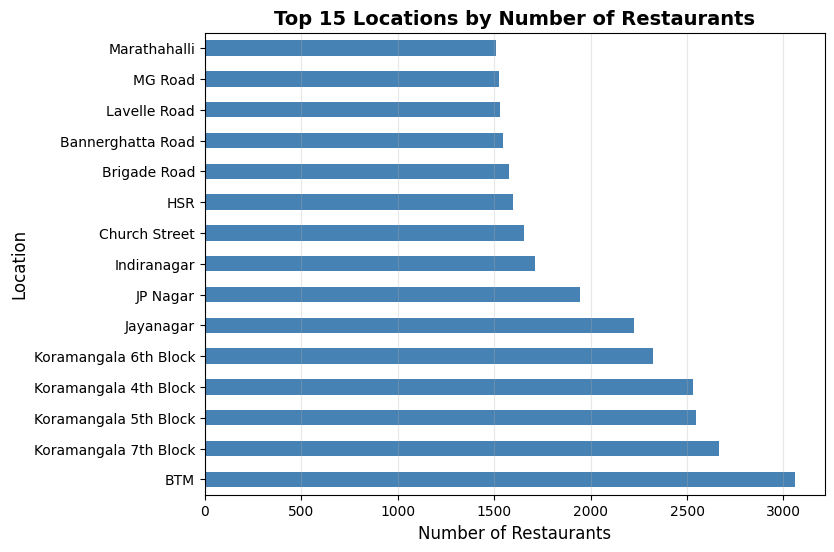

In [46]:
plt.figure(figsize=(8, 6))
location_counts = df['listed_in(city)'].value_counts().head(15)
location_counts.plot(kind='barh', color='steelblue')
plt.title('Top 15 Locations by Number of Restaurants', fontsize=14, fontweight='bold')
plt.xlabel('Number of Restaurants', fontsize=12)
plt.ylabel('Location', fontsize=12)
plt.grid(axis='x', alpha=0.3)

2. Top 10 Restaurant Types in Bangalore

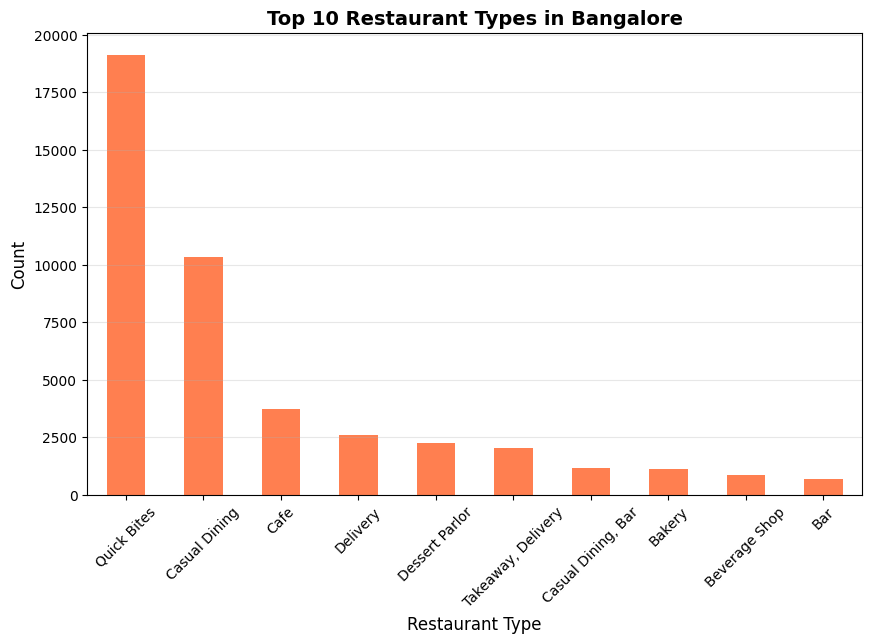

In [47]:
plt.figure(figsize=(10, 6))
rest_type = df['rest_type'].value_counts().head(10)
rest_type.plot(kind='bar', color='coral')
plt.title('Top 10 Restaurant Types in Bangalore', fontsize=14, fontweight='bold')
plt.ylabel('Count', fontsize=12)
plt.xlabel('Restaurant Type', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)

3. Distribution of Rating

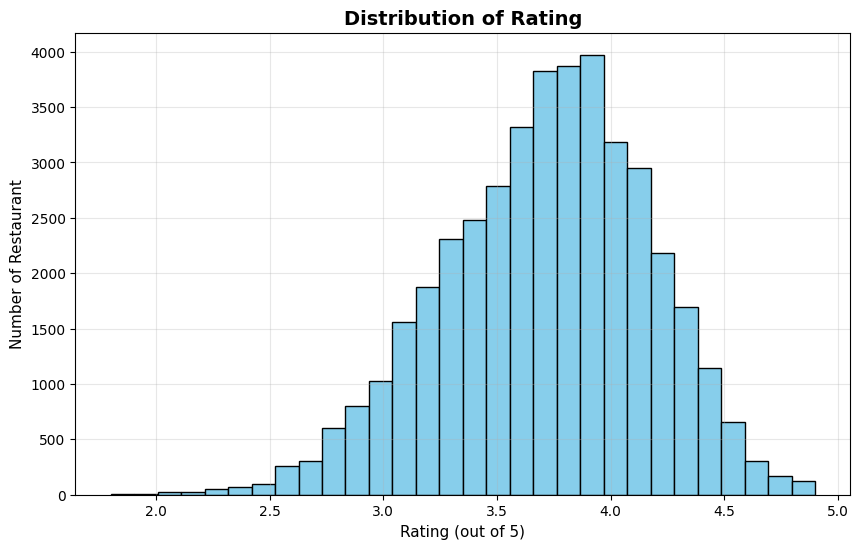

In [48]:
plt.figure(figsize=(10,6))
plt.hist(df['rate'], bins=30, color='skyblue', edgecolor='black')
plt.xlabel('Rating (out of 5)', fontsize=11)
plt.ylabel('Number of Restaurant', fontsize=11)
plt.title('Distribution of Rating', fontsize=14, fontweight='bold')
plt.grid(alpha=0.3)

4. Rating Distribution

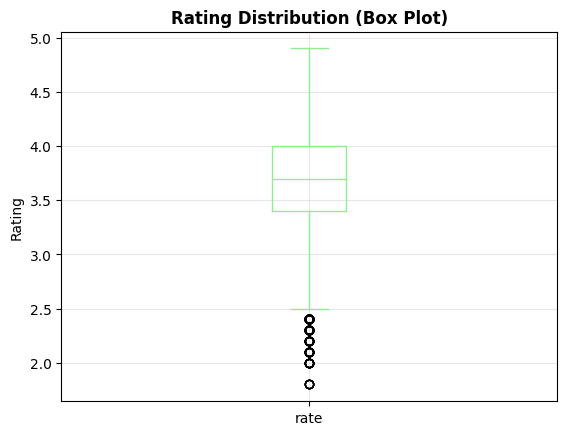

In [49]:
df['rate'].plot(kind='box', color='lightgreen')
plt.title('Rating Distribution (Box Plot)', fontsize=12, fontweight='bold')
plt.ylabel('Rating')
plt.grid(alpha=0.3)

5. Distribution of Cost for 2 People

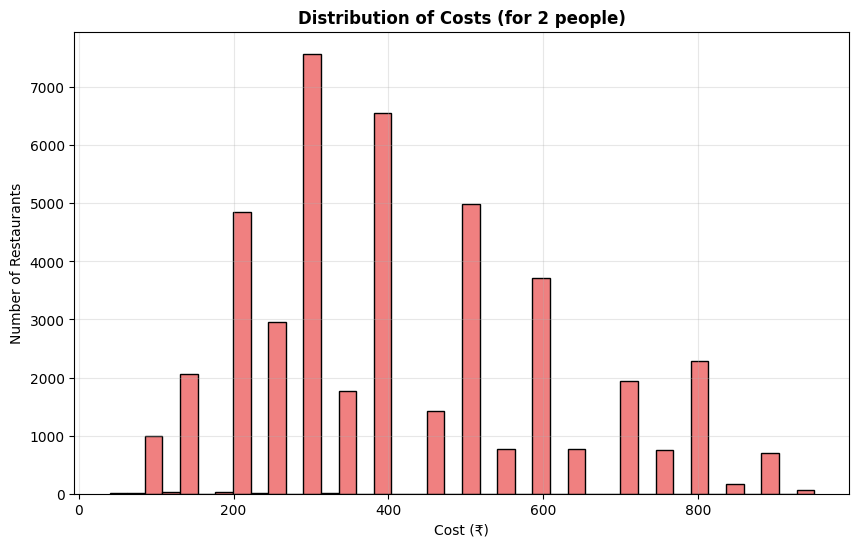

In [50]:
plt.figure(figsize=(10,6))
plt.hist(df['approx_cost(for two people)'].dropna(), bins=40, color='lightcoral', edgecolor='black')
plt.title('Distribution of Costs (for 2 people)', fontsize=12, fontweight='bold')
plt.xlabel('Cost (₹)')
plt.ylabel('Number of Restaurants')
plt.grid(alpha=0.3)

6. Ratings of Expensive Restaurants

* This chart is made to analyse that 'Do Expensive Restaurant Have Better Ratings?'

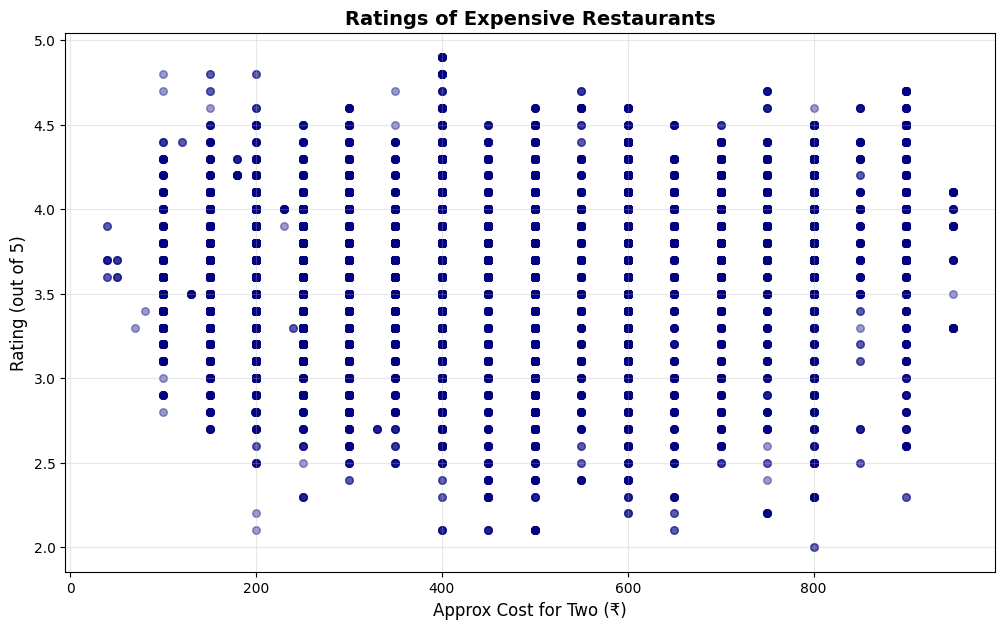

In [51]:
df_plot = df[(df['approx_cost(for two people)'] < 2000) & (df['rate'] > 0)]
 
plt.figure(figsize=(12, 7))
plt.scatter(df_plot['approx_cost(for two people)'], df_plot['rate'], alpha=0.4, s=30, color='navy')
plt.xlabel('Approx Cost for Two (₹)', fontsize=12)
plt.ylabel('Rating (out of 5)', fontsize=12)
plt.title('Ratings of Expensive Restaurants', fontsize=14, fontweight='bold')
plt.grid(alpha=0.3)

## Key Findings

### 1. Location Insights
- **Lavelle Road** leads with the highest average rating of 4.14/5 with 487 restaurants
- **Koramangala 5th Block** has the largest concentration with 2,319 restaurants
- **St. Marks Road** and **Koramangala 3rd Block** both maintain 4.02 average ratings
- Premium areas like Lavelle Road and St. Marks Road show higher ratings despite having fewer restaurants, indicating quality over quantity

### 2. Restaurant Type Distribution
- **Casual Dining** dominates Bangalore's restaurant market as the most common type
- **Pubs, Lounge, and Bar** categories show the highest average costs (₹850-900 for two)
- **Quick Bites** and **Bakery** establishments are budget-friendly while maintaining quality

### 3. Cost vs. Rating Analysis
- **No strong direct correlation** between price and rating - expensive restaurants don't necessarily have higher ratings
- Many high-rated restaurants (4.6-4.8 rating) operate at budget-friendly price points (₹100-300 for two people)
- The analysis found 20 value restaurants meeting the criteria of rating ≥4.0 and cost ≤₹350

### 4. Value Restaurants Identified
- **Brahmin's Coffee Bar** (Basavanagudi): 4.8 rating, ₹100 cost
- **CTR** (Malleshwaram): 4.7-4.8 rating, ₹150 cost
- **Taaza Thindi** (Banashankari): 4.7 rating, ₹100 cost
- **The Pancake Story** (Koramangala 1st Block): 4.6 rating, ₹300 cost
- Multiple dessert parlors and ice cream shops maintain 4.6+ ratings at budget prices

### 5. Data Quality Observations
- Original dataset had 60,782 records; after cleaning, 56,236 valid records remain
- 4,745 duplicate records were identified
- ~12,368 null values in ratings and ~11,000+ nulls in cost data
- Despite missing values, sufficient data remains for meaningful analysis

## Recommendations

### For Consumers
1. Don't assume higher prices guarantee better ratings - explore budget-friendly, highly-rated options
2. Check location-based ratings - areas like Lavelle Road and St. Marks Road have consistently higher quality
3. Quick bites and bakeries offer excellent value propositions

### For Restaurant Owners
1. Quality and service matter more than price - competitive rating at lower costs indicates good management
2. Location choice significantly impacts rating perception
3. Quick service restaurants show strong customer satisfaction even at lower price points

### For Future Analysis
1. Incorporate time-series data to track rating trends
2. Analyze cuisine preferences by location
3. Study the impact of online ordering availability on ratings
4. Perform sentiment analysis on customer reviews for deeper insights